<a href="https://colab.research.google.com/github/yuki-gu/ai-colab-notebooks/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 参考
[言語理解のためのTransformerモデル - TensorFlow Ja](https://www.tensorflow.org/text/tutorials/transformer?hl=ja)

[Attention Is All You Need](https://arxiv.org/pdf/1706.03762)

([Accelerating PyTorch Transformers - PyTorch](https://docs.pytorch.org/tutorials/intermediate/transformer_building_blocks.html))

### Pytorch

【Dataset】
tokenizer
・encode: "word word" -> [0, 1, 2]
・decode: [0, 1, 2] -> "word word"
・vocab dict: {}

<bos>, <eos>
・encoder_input = [id(bos)] + [0, 1, 2] + [id(eos)]
・decoder_input = [id(bos)] + [0, 1, 2]
・decoder_target = [0, 1, 2] + [id(eos)]
・ <= max_length でないものを削除

batch: (batch_size, seq_len)
・add <pad> (batch内のmax)



【Model】
Embedding: index(range=vocab_size) -> vector(size=dim_model)
・[0, 1, 2] -> [[0.1, -0.1], [1.6, 0.2], [-2.0, 0.0]]
・(batch_size, seq_len) -> (batch_size, seq_len, dim_model)

Pos_Encoding(seq_len, dim_model)
・Add
・Embedding(max_seq_len -> dim_model)

Mask
・padding_mask [batch_size, seq_len]: <pad>の時True(1)
　・encoder self-attention inputs (encoder inputから生成)
　・decoder cross-attention from encoder (encoder inputから生成) → cross-attentionのmaskに渡す
　・decoder self-attention inputs (decoder inputから生成) → look_ahead_maskと結合
・look_ahead_mask(decoder masked-self-attention) [seq_len, seq_len]: 右上三角
・target padding_mask(loss_fn): Crossentropy * mask

Decodere final layer
・(batch_size, seq_len, dim_model) -> (batch_size, seq_len, vocab_size)

forward(input,
・encoder(input, encoder_padding_mask)
・decoder(decoder_input, encoder_output, look_ahead_mask+padding_mask, encoder_output_mask)

num_layers=6, d_model = 512, dff = 2048

generate
・decoder_start_token = [<bos>]
・prediction(batch_size, seq_len, vocab_size) -> last_pred(batch_size, vocab_size)
・argmax(last_pred) -> pred_id(batch_size)
・pred_id == <eos>: end
・decoder_input = concatinate(pred_id)

In [ ]:
import collections
import logging
import os
import pathlib
import re
import string
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
import tensorflow_text as text
import tensorflow as tf

### モデル構造

#### パーツ

### Scaled Dot-Product Attention

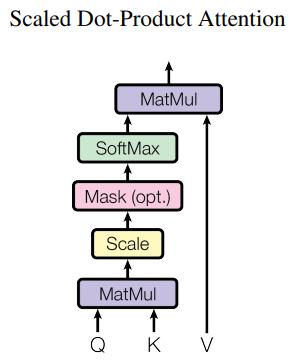

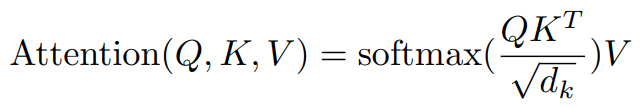

<br>

Input: Query, (Key, Value)

Output: Valueの重み付き和 (重みはQueryとKeyから計算)

$ d_k $ : Query/Key dimension

$ d_v $ : Value dimension

$ d_k $ でのScaling : Softmaxの入力 $ QK^T $ が大きくなり, 初期化時にSoftmaxが飽和するのを防ぐため

1つのQueryに1つのOutput : 全てのKeyとのdot積を重みとし, Valueを合計する

行列演算として全てのQueryに対するAttentionを同時に計算


In [ ]:
# @title Scaled Dot-Product Attention (単一Attention)
def scaled_dot_product_attention(q, k, v, mask):
  """Calculate the attention weights.
  q, k, v must have matching leading dimensions.
  k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
  The mask has different shapes depending on its type(padding or look ahead)
  but it must be broadcastable for addition.

  Args:
    q: query shape == (..., seq_len_q, depth)
    k: key shape == (..., seq_len_k, depth)
    v: value shape == (..., seq_len_v, depth_v)
    mask: Float tensor with shape broadcastable
          to (..., seq_len_q, seq_len_k). Defaults to None.

  Returns:
    output, attention_weights
  """

  matmul_qk = tf.matmul(q, k, transpose_b=True)  # QK^T (seq_len_q, seq_len_k) (transpose_b: 転置^T)

  # scale matmul_qk
  dk = tf.cast(tf.shape(k)[-1], tf.float32)  # kの最後次元
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)  # / \sqrt{d_k}

  # add the mask to the scaled tensor.
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)  # 1(隠す部分)を"-∞"(-大きな数字)にする

  # softmax is normalized on the last axis (seq_len_k) so that the scores
  # add up to 1.
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # 最後の軸(seq_len_k)の合計が1 (seq_len_q, seq_len_k)

  output = tf.matmul(attention_weights, v)  # (seq_len_q, d_v)

  return output, attention_weights

### Multi-Head Attention

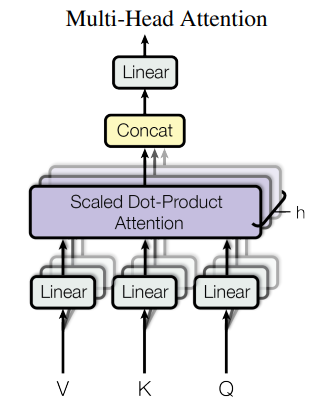

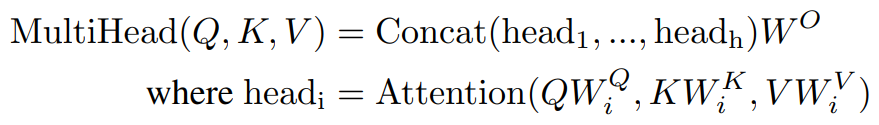

<br>

単一Attention : $ d_k = d_v = d_{model} $

Head数 : $ h = 8 $

$ d_k = d_v = d_{model}/h = 64 $

それぞれ学習済みの線形投影(重みとの行列積)で変換 (* h個)

: 次元圧縮により総計算コストは単一Attentionと同程度

- Q : $ d_{model} \to d_k $
- K : $ d_{model} \to d_k $
- V : $ d_{model} \to d_v $

3($ W^Q $,$ W^K $,$ W^V $) * h(Head数) の重み行列が存在

h個の出力値($ d_v $次元) -> 連結(Concat) -> 線形投影($ W^O $との行列積)

$ W^O $ : $ h \cdot d_v \to d_{model} $

<br>

シーケンス長 : Qと(K,V)で別 (正方形でないAttention行列ができる, qごとにseq_len_kのsoftmax重みでV内のベクトルを重み付き和)

次元 : (Q, K)とVで別 (同じ次元で類似度計算, softmax値で単純に足し合わせるだけ)

- Q : (seq_len_q, d_k) (行,列)
- K : (seq_len_k, d_k)
- V : (seq_len_k, d_v)
- O : (d_v, d_model)
- $ QK^T $ : (seq_len_q, seq_len_k) (d_kが一致) : 1行のquery(tokenのvector表現)に対してseq_len_k個のkey(全てのtoken)とのベクトルの類似度が計算される
- softmax : (seq_len_q, seq_len_k) (qごとに適応(1, seq_len_k)) : 1行のquery(1 token)に対して全てのtokenの類似度の合計が1になる
- softmax()V : (seq_len_q, d_v) (seq_len_kが一致, (1, seq_len_k)に値が積和) : 類似度に対応するvalue(tokenのvector表現)が重みづけされ足し合わされる
- *O : (seq_len_q, d_model) : 足し合わされた値の次元を元の次元に戻す

In [ ]:
# @title Multi-Head Attention

# Multi-Head Attention
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads  # 8
    self.d_model = d_model  # 512

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads  # 512 / 8 = 64

    # 個別適用 8 * Dense(64) ではなく, Dense(64*8)の後に8分割する (単純化)
    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)

    self.dense = tf.keras.layers.Dense(d_model)  # W^O

  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))  # (batch_size, seq_len, 512) -> (batch_size, seq_len, 8, 64)
    return tf.transpose(x, perm=[0, 2, 1, 3])  # (batch_size, 8, seq_len, 64)

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]

    # Linear
    q = self.wq(q)  # (batch_size, seq_len, d_model)
    k = self.wk(k)  # (batch_size, seq_len, d_model)
    v = self.wv(v)  # (batch_size, seq_len, d_model)

    # Linearの後からheadsに分割
    q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth) (None, 8, seq_len, 64) : headごとに(seq_len, 64)
    k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
    v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

    # 個別適用 : scaled_dot_product_attentionは (..., seq_len, depth) の形状に対応
    scaled_attention, attention_weights = scaled_dot_product_attention(
        q, k, v, mask)
    # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
    # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)

    # 元の形状に戻す
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)
    # Concat
    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

    # Linear (W^O)
    output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

    return output, attention_weights

### Position-wise Feed-Forward Network
- 各トークンに対して個別に適用
- 重みは同一のものを使う (layer間は異なる重み)
  - 2 * 畳み込み(kernel size = 1)
- Linear -> ReLU -> Linear
- 内部の次元 : $ d_{ff} = 2048 $

<br>

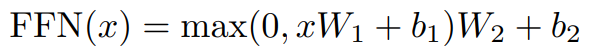

In [ ]:
# @title Feed Forward
def point_wise_feed_forward_network(d_model, dff):  # dff=2048
  return tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),  # (512) -> Linear(dff) -> ReLU  (batch_size, seq_len, dff)
      tf.keras.layers.Dense(d_model)  # -> Linear(512)  (batch_size, seq_len, d_model)
  ])

### Embedding
- 意味が同じトークンは近い位置になるように
- 学習済みのEmbeddingを用いる
- token index -> vector(len = $ d_{model} $)
- Input Embedding, Output Embedding, 出力用のLinear で同じ重みを共有
  - Embeddingでは 重み * $ \sqrt{d_{model}} $


In [ ]:
# @title Input Embedding


### Positional Encoding
必要性 : Attention Layerは入力トークンの順番を考慮しない (単なる行列演算)

→ 単語の順番が入れ替わった文章でも同じと見なしてしまう

<br>

Positional Encoding : トークンの位置(相対 or 絶対) の情報を含める (位置が近いと意味も近くなるように)
- Input : Embedding後の行列
- Output : Embedding後の行列 + 位置埋め込み
- 2つは同じ次元 : (seq_len, $ d_{model} $)

<br>

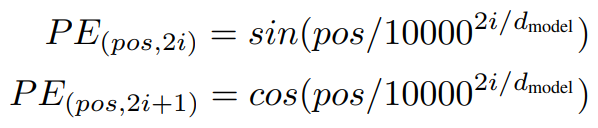

<br>

- pos : tokenの位置 $ [0, seq\_len-1] $
- i : $ [0, d_{model}-1] $

In [ ]:
# @title Positional Encoding

# sin, cos の中身を計算
def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
  return pos * angle_rates


def positional_encoding(position, d_model):  # position=2048, d_model=512
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],  # [0, position - 1]
                          np.arange(d_model)[np.newaxis, :],  # [0, d_model - 1]
                          d_model)
  # print(angle_rads.shape)  # (2048, 512)

  # 偶数(2i)にsinを適用
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

  # 奇数(2i+1)にcosを適用
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

  pos_encoding = angle_rads[np.newaxis, ...]
  # print(pos_encoding.shape)  # (1, 2048, 512)

  return tf.cast(pos_encoding, dtype=tf.float32)




---

### Attentionの種類
encoder-decoder attention
- Q : DecoderLayer
- K,V : EncoderOutput
- Decoderの1つのqueryが, Encoderのkeyの全てにattentionできる (seq2seqのAttention)
- Encoderの値を出力(Value) -> Decoderの値と残差接続

encoder self-attention
- Q,K,V : EncoderLayer
- 1つのqueryがkeyの全てにattention

decoder self-attention
- Softmaxの入力を"−∞"でmask

### Encoder

Encoder = EncoderLayer * 6 (N = 6)

EncoderLayer = "Multi-Head Self-Attention" + "Positionwise Fully Connected Feed-Forward Network"

EncoderLayer内の2つのSublayerの出力 → Add (残差接続) → Layer Normalization

: LayerNorm(x + Sublayer(x))

output dimension : $ d_{model} = 512 $
→ 残差接続を容易にするため

In [ ]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()

    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)  # 最後の次元(d_model)で正規化
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)

  def call(self, x, training, mask):
    # Multi-Head Self-Attention
    attn_output, _ = self.mha(x, x, x, mask)  # Q = K = V = x (Self-Attention) maskは行わない  (batch_size, input_seq_len, d_model)
    attn_output = self.dropout1(attn_output, training=training)  # Sublayerを使うか選択
    out1 = self.layernorm1(x + attn_output)  # Add -> Layer Normalization  (batch_size, input_seq_len, d_model)

    # Positionwise Fully Connected Feed-Forward Network
    ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
    ffn_output = self.dropout2(ffn_output, training=training)  # Sublayerを使うか選択
    out2 = self.layernorm2(out1 + ffn_output)  # Add -> Layer Normalization  (batch_size, input_seq_len, d_model)

    return out2



class Encoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Encoder, self).__init__()

    self.d_model = d_model  # 512
    self.num_layers = num_layers  # 6

    self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)  # 埋め込み
    self.pos_encoding = positional_encoding(maximum_position_encoding,  # 最大シーケンス長 -> 実際のシーケンス長で切り取り
                                            self.d_model)

    self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate)
                       for _ in range(num_layers)]

    self.dropout = tf.keras.layers.Dropout(rate)

  def call(self, x, training, mask):

    seq_len = tf.shape(x)[1]  # (batch_size, input_seq_len)

    # adding embedding and position encoding.
    x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # 重み共有の重みづけ (\sqrt{d_model})
    x += self.pos_encoding[:, :seq_len, :]  # + Positional Encoding (固定長ベクトル)

    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x, training, mask)  # mask = None

    return x  # (batch_size, input_seq_len, d_model)

### Decoder

Decoder = DecoderLayer * 6 (N = 6)

DecoderLayer = "Masked Multi-Head Self-Attention (より後ろのAttention Weightを0に)" + "Multi-Head Attention (encoder output)" + "Positionwise Fully Connected Feed-Forward Network"

Encoderと同様 : Add → Norm

In [ ]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(DecoderLayer, self).__init__()

    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)

    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    self.dropout3 = tf.keras.layers.Dropout(rate)

  # 呼び出すにはenc_outputが必要
  def call(self, x, enc_output, training,
           look_ahead_mask, padding_mask):
    # enc_output.shape == (batch_size, input_seq_len, d_model)

    # Masked Multi-Head Self-Attention
    attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)  # Q = K = V = x (Self-Attention) maskを適用  (batch_size, target_seq_len, d_model)
    attn1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(attn1 + x)  # Add -> Layer Normalization

    # Multi-Head Attention (encoder output)
    attn2, attn_weights_block2 = self.mha2(
        enc_output, enc_output, out1, padding_mask)  # Q = DecoderLayer, (K, V) = EncoderOutput  maskは<pad>のみ  (batch_size, target_seq_len, d_model)
    attn2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(attn2 + out1)  # Add -> Layer Normalization  (batch_size, target_seq_len, d_model)

    # Positionwise Fully Connected Feed-Forward Network
    ffn_output = self.ffn(out2)  # (batch_size, target_seq_len, d_model)
    ffn_output = self.dropout3(ffn_output, training=training)
    out3 = self.layernorm3(ffn_output + out2)  # Add -> Layer Normalization  (batch_size, target_seq_len, d_model)

    return out3, attn_weights_block1, attn_weights_block2


class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
               maximum_position_encoding, rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model  # 512
    self.num_layers = num_layers  # 6

    self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)
    self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

    self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate)
                       for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(rate)

  # 呼び出すにはenc_outputが必要
  def call(self, x, enc_output, training,
           look_ahead_mask, padding_mask):

    seq_len = tf.shape(x)[1]
    attention_weights = {}

    x = self.embedding(x)  # (batch_size, target_seq_len, d_model)
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x += self.pos_encoding[:, :seq_len, :]

    x = self.dropout(x, training=training)

    for i in range(self.num_layers):
      x, block1, block2 = self.dec_layers[i](x, enc_output, training,
                                             look_ahead_mask, padding_mask)

      attention_weights[f'decoder_layer{i+1}_block1'] = block1
      attention_weights[f'decoder_layer{i+1}_block2'] = block2

    # x.shape == (batch_size, target_seq_len, d_model)
    return x, attention_weights

### 出力
- Linear -> Softmax

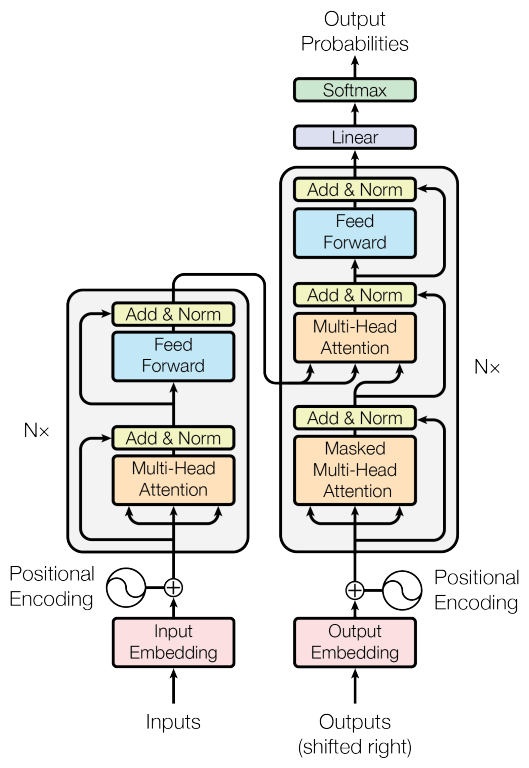

In [ ]:
# @title Transformer
class Transformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
               target_vocab_size, pe_input, pe_target, rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                             input_vocab_size, pe_input, rate)

    self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                           target_vocab_size, pe_target, rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)  # Linear


  def call(self, inputs, training):
    # Keras models prefer if you pass all your inputs in the first argument
    inp, tar = inputs

    enc_padding_mask, look_ahead_mask, dec_padding_mask = self.create_masks(inp, tar)

    # まずEncoderに通す
    enc_output = self.encoder(inp, training, enc_padding_mask)  # (batch_size, inp_seq_len, d_model)

    # enc_outputを使ってDecoderを計算
    # targetを入力してDecoder出力を並列計算 (前ステップで何を出力しても正しい値を入力する)
    dec_output, attention_weights = self.decoder(
        tar, enc_output, training, look_ahead_mask, dec_padding_mask)
    # dec_output.shape == (batch_size, tar_seq_len, d_model)

    final_output = self.final_layer(dec_output)  # Linearでlogitsを生成  (batch_size, tar_seq_len, target_vocab_size)

    return final_output, attention_weights  # final_outputをSoftmaxに通したものが最終出力

  def create_masks(self, inp, tar):
    # padding mask : Encoder Multi-Head Self-Attention
    enc_padding_mask = create_padding_mask(inp)

    # padding mask : Decoder Multi-Head Attention (mask the encoder outputs)
    dec_padding_mask = create_padding_mask(inp)

    # look ahead mask : Decoder Masked Multi-Head Self-Attention
    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])  # シーケンス長
    dec_target_padding_mask = create_padding_mask(tar)  # padding mask
    look_ahead_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

    return enc_padding_mask, look_ahead_mask, dec_padding_mask



# Input mask
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)  # mask: <pad>の場所が1, それ以外が0

  # add extra dimensions to add the padding to the attention logits.
  return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)


# Masked Multi-Head Attention
def create_look_ahead_mask(size):
  # 使用しない場所が1になる
  # size=3
  # [0 1 1]
  # [0 0 1]
  # [0 0 0]
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
  return mask  # (seq_len, seq_len)

---

### 学習条件
- 最適化関数 : Adam ($ \beta_1 = 0.9, \beta_2 = 0.98, \epsilon = 10^{-9} $)
- 学習率 : 4000stepのwarmup(線形増加), $ step^{-0.5} $に比例して減少
- 位置埋め込みの直後にDropout(0.1)
- SubLayerの直後にDropout(0.1) : sublaを通さない選択
- Label Smoothing(0.1) : 正解ラベルを0/1よりも曖昧にする


In [ ]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    arg1 = tf.math.rsqrt(step)  # minの1項目 (sqrtの逆数)
    arg2 = step * (self.warmup_steps ** -1.5)  # minの2項目

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')  # Crossentropy(Softmax前の出力を入力)

def loss_function(real, pred):
  # 教師データのパディング
  mask = tf.math.logical_not(tf.math.equal(real, 0))  # <pad>の位置は0, それ以外が1

  loss_ = loss_object(real, pred)
  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask  # <pad>の位置を0にする

  return tf.reduce_sum(loss_)/tf.reduce_sum(mask)


def accuracy_function(real, pred):
  accuracies = tf.equal(real, tf.argmax(pred, axis=2))  # predのvocab_sizeの確率maxが予測値

  mask = tf.math.logical_not(tf.math.equal(real, 0))
  accuracies = tf.math.logical_and(mask, accuracies)

  accuracies = tf.cast(accuracies, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(accuracies)/tf.reduce_sum(mask)

In [ ]:
# @title 学習
def train_step(inp, tar):
  # inp : ポルトガル語
  # tar : 英語

  tar_inp = tar[:, :-1]  # トークン列
  tar_real = tar[:, 1:]  # tar_inpのトークン列を1つだけ左にずらしたもの

  with tf.GradientTape() as tape:
    predictions, _ = transformer([inp, tar_inp],  # Encoder入力, Decoder入力
                                 training = True)
    loss = loss_function(tar_real, predictions)  # Decoder出力(正解), Decoder出力(予測)

  gradients = tape.gradient(loss, transformer.trainable_variables)  # 微分して勾配計算
  optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))  # optimizerで重み更新

  train_loss(loss)
  train_accuracy(accuracy_function(tar_real, predictions))


inp, tar = next(iter(train_batches))
train_step(inp, tar)


In [ ]:
# @title 推論 (順番に出力)

class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=20):
    # sentence: ポルトガル語のstring
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.pt.tokenize(sentence).to_tensor()  # トークン化(ポルトガル語のTokenizerを利用) → Encoder入力
    encoder_input = sentence

    start_end = self.tokenizers.en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]  # 開始トークン [START]
    end = start_end[1][tf.newaxis]  # 終了トークン

    # tf.TensorArrayで動作をトレースできるように
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)  # Decoder入力の初期値は [START]

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack())
      # 実際のモデルは推論時に最後のトークンだけを計算する
      predictions, _ = self.transformer([encoder_input, output], training=False)  # (入力文, [[START]])
      # ・入力値からmaskを計算
      # ・Encoder出力を計算(入力文)
      # ・Decoder出力を計算([START])

      # 予測結果から最後のトークンを取得
      predictions = predictions[:, -1:, :]  # (batch_size, seq_len, vocab_size) -> (batch_size, 1, vocab_size)

      predicted_id = tf.argmax(predictions, axis=-1)  # 予測を取得

      # 予測結果をデコーダー入力に連結
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:  # 終了トークン
        break

    # 出力をテキストに変換
    output = tf.transpose(output_array.stack())
    # output.shape (1, tokens)
    text = tokenizers.en.detokenize(output)[0]  # shape: ()

    tokens = tokenizers.en.lookup(output)[0]


    # (最後のattention_weightsが破棄されるため空実行)
    _, attention_weights = self.transformer([encoder_input, output[:,:-1]], training=False)

    return text, tokens, attention_weights


# 出力文だけを返すモデル
class ExportTranslator(tf.Module):
  def __init__(self, translator):
    self.translator = translator  # wrap

  @tf.function(input_signature=[tf.TensorSpec(shape=[], dtype=tf.string)])
  def __call__(self, sentence):
    (result,
     tokens,
     attention_weights) = self.translator(sentence, max_length=100)

    return result